# Assignment 7 – EDA

# Name - Dhrupad Kumar Das

## Import the attached CSV files (IPL_Dataset.csv) and answer the following questions:

## Q1. What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.


In [1]:
import numpy as np
import pandas as pd

In [2]:
IPL_Dataset = pd.read_excel('IPL Dataset Assignment.xlsm')
IPL_Dataset

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0


In [3]:
Max_Matches_Player = IPL_Dataset.groupby('Player')['Matches'].count().reset_index()
Max_Matches_Player = IPL_Dataset.sort_values(by= 'Matches', ascending = False).head(5).copy()
print(Max_Matches_Player[['Player', 'Matches']])

             Player  Matches
3      Shreyas Iyer       17
1    Shikhar Dhawan       17
67    Kagiso Rabada       17
19   Marcus Stoinis       17
114     T Natarajan       16


## Q2. Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [4]:
IPL_Dataset = IPL_Dataset.rename(columns = {50: "Half_Century", 100: 'Century'})
IPL_Dataset

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,Century,Half_Century,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0


In [5]:
More_than_2_Half_Century = IPL_Dataset[IPL_Dataset['Half_Century'] >= 2]
Top_2_Player = More_than_2_Half_Century.sort_values(by = 'Avg', ascending = False).copy()
Top_2_Players = Top_2_Player.head(2)
print(Top_2_Players[['Player','Half_Century','Avg']])

             Player  Half_Century    Avg
36  Wriddhiman Saha             2  71.33
4      Ishan Kishan             4  57.33


## Q3. Create 2 new columns based on Player name. First column will have first name and second column will have last name. Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [10]:
IPL_Dataset[['First_Name', 'Last_Name']] = IPL_Dataset['Player'].str.split(" ", n = 1, expand= True).copy()
print(IPL_Dataset[['Player', 'First_Name', 'Last_Name']])

                Player First_Name Last_Name
0             KL Rahul         KL     Rahul
1       Shikhar Dhawan    Shikhar    Dhawan
2         David Warner      David    Warner
3         Shreyas Iyer    Shreyas      Iyer
4         Ishan Kishan      Ishan    Kishan
..                 ...        ...       ...
128      Khaleel Ahmed    Khaleel     Ahmed
129     Arshdeep Singh   Arshdeep     Singh
130        Daniel Sams     Daniel      Sams
131  Shreevats Goswami  Shreevats   Goswami
132        Trent Boult      Trent     Boult

[133 rows x 3 columns]


## Q4. Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [11]:
IPL_Dataset['Cleaned_Highest_Score'] = IPL_Dataset['Highest Score'].str.replace('*','', regex = False)
IPL_Dataset['Cleaned_Highest_Score'] = IPL_Dataset['Cleaned_Highest_Score'].fillna(0)
IPL_Dataset['Cleaned_Highest_Score'] = IPL_Dataset['Cleaned_Highest_Score'].astype(int)
print(IPL_Dataset[['Highest Score','Cleaned_Highest_Score']])

    Highest Score  Cleaned_Highest_Score
0            132*                    132
1            106*                    106
2             85*                     85
3             88*                     88
4              99                      0
..            ...                    ...
128            0*                      0
129            0*                      0
130            0*                      0
131            0*                      0
132            0*                      0

[133 rows x 2 columns]


## Q5. Print the total number of centuries scored in the entire season.

In [12]:
Total_Centuries = IPL_Dataset['Century'].sum()
print("Total number of centuries scored in the entire season:", Total_Centuries)

Total number of centuries scored in the entire season: 5


## Q6. Print all the player names whose strike rate is less than the average strike rate of all players in entire season. Print the player name, his strike rate and average strike rate.

In [13]:
average_strike_rate = IPL_Dataset['Strike rate'].mean()
average_strike_rate = round(average_strike_rate, 2)

filtered_players = IPL_Dataset[IPL_Dataset['Strike rate'] < average_strike_rate]
filtered_players['Average Strike Rate'] = average_strike_rate

print("Players with strike rate below average:")
print(filtered_players[['Player', 'Strike rate', 'Average Strike Rate']])

Players with strike rate below average:
                  Player  Strike rate  Average Strike Rate
51        Ajinkya Rahane       105.60               107.36
55         Glenn Maxwell       101.88               107.36
58         Vijay Shankar       101.04               107.36
61         Josh Philippe       101.29               107.36
62       Gurkeerat Singh        88.75               107.36
65          Kedar Jadhav        93.93               107.36
70      Yashasvi Jaiswal        90.90               107.36
71         Shreyas Gopal        94.87               107.36
77          Murali Vijay        74.41               107.36
79          Chris Jordan        93.54               107.36
80         Navdeep Saini       100.00               107.36
82     Kamlesh Nagarkoti        70.96               107.36
84         Harshal Patel        87.50               107.36
85         Jimmy Neesham       105.55               107.36
86            Tom Banton        90.00               107.36
89     Prabhsimr

C:\Users\user\AppData\Local\Temp\ipykernel_9436\1311890223.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_players['Average Strike Rate'] = average_strike_rate


## Q7. Please check the correlation between the features and create a heat map.

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.artist

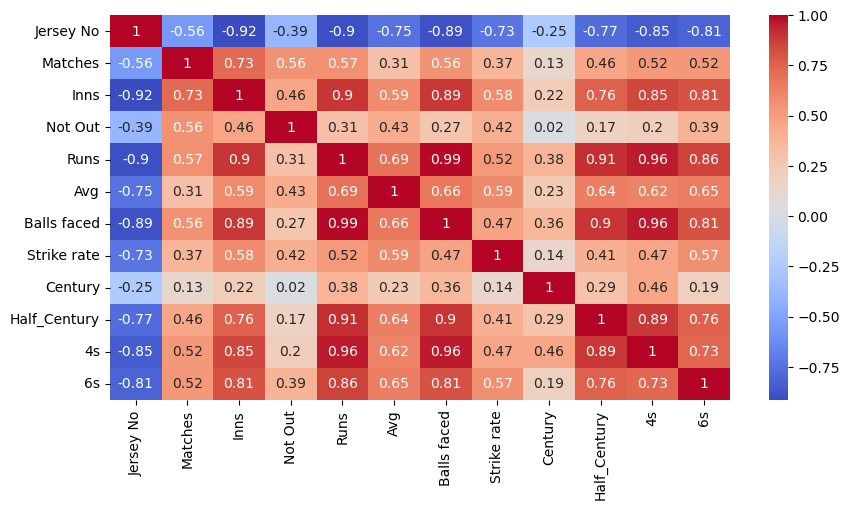

In [16]:
IPL_Corr = IPL_Dataset.select_dtypes(include = ['float64', 'int64'])
sns.heatmap(IPL_Corr.corr(), annot= True, cmap= 'coolwarm')
plt.rcParams['figure.figsize']=[10,5]
plt.show()

## From the above figure we can infer that there is a very strong correlation between:
## 1) Innings played with (Runs, balls faced, Half Century, 4s, 6s)
## 2) Runs with (Balls faced, Half century, 4s, 6s)
## 3) Balls faced with (Half century, 4s and 6s)
## 4) Half Century with (4s, 6s)

## Q8. Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.

In [17]:
filtered_players = IPL_Dataset[(IPL_Dataset['Avg'] > 50) & (IPL_Dataset['Strike rate'] > 120)]

print(filtered_players[['Player', 'Avg', 'Strike rate']])

             Player     Avg  Strike rate
0          KL Rahul   55.83       129.34
4      Ishan Kishan   57.33       145.76
31   Kieron Pollard   53.60       191.42
36  Wriddhiman Saha   71.33       139.86
37  Ruturaj Gaikwad   51.00       120.71
57     Deepak Hooda  101.00       142.25
60       Tom Curran   83.00       133.87


## Q9. Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [18]:
Players_list = IPL_Dataset[(IPL_Dataset['Avg']> 40) & (IPL_Dataset['Balls faced'] >100)]
print("PLAYERS WITH AVG > 40 AND BALLS FACED > 100:")
print(Players_list[['Player', 'Avg', 'Balls faced']])

PLAYERS WITH AVG > 40 AND BALLS FACED > 100:
             Player    Avg  Balls faced
0          KL Rahul  55.83          518
1    Shikhar Dhawan  44.14          427
4      Ishan Kishan  57.33          354
8       Virat Kohli  42.36          384
9      ABD Villiers  45.40          286
10    Faf Duplessis  40.81          319
14      Eoin Morgan  41.80          302
24  Kane Williamson  45.28          237
27      Chris Gayle  41.14          210
28       Ben Stokes  40.71          200
31   Kieron Pollard  53.60          140
32    Rahul Tewatia  42.50          183
33  Ravindra Jadeja  46.40          135
36  Wriddhiman Saha  71.33          153
37  Ruturaj Gaikwad  51.00          169


## Q10. Players who scored atleast one century in this season. Create visualization.

In [19]:
Players_with_centuries = IPL_Dataset[IPL_Dataset['Century']>= 1]
print(Players_with_centuries[['Player','Century']])

            Player  Century
0         KL Rahul        1
1   Shikhar Dhawan        2
13  Mayank Agarwal        1
28      Ben Stokes        1


C:\Users\user\AppData\Local\Temp\ipykernel_9436\162932930.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= 'Player', y= 'Century', data= Players_with_centuries, palette = "viridis")


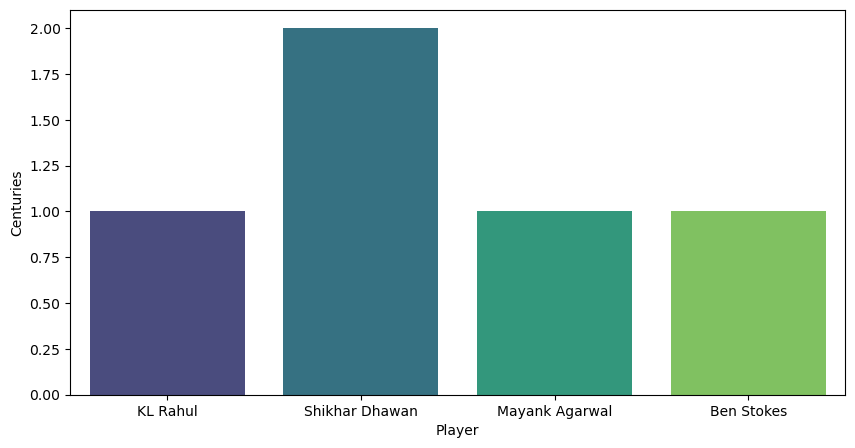

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize= (10,5))
sns.barplot(x= 'Player', y= 'Century', data= Players_with_centuries, palette = "viridis")
plt.xlabel('Player')
plt.ylabel('Centuries')
plt.show()

## Q11. Players who scored atleast 4 half centuries in this season.

In [21]:
Player_with_4_half_centuries = IPL_Dataset[IPL_Dataset['Half_Century']>=4]
print(Player_with_4_half_centuries[['Player', 'Half_Century']])

              Player  Half_Century
0           KL Rahul             5
1     Shikhar Dhawan             4
2       David Warner             4
4       Ishan Kishan             4
5       Quinton Kock             4
6   Suryakumar Yadav             4
7   Devdutt Padikkal             5
9       ABD Villiers             5
10     Faf Duplessis             4


## Q12. Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [22]:
More_boundaries_six = IPL_Dataset[(IPL_Dataset['4s']>45) & (IPL_Dataset['6s']>10)]
print(More_boundaries_six[['Player','4s','6s']])

             Player  4s  6s
0          KL Rahul  58  23
1    Shikhar Dhawan  67  12
2      David Warner  52  14
5      Quinton Kock  46  22
6  Suryakumar Yadav  61  11


## Q13. Plot a histogram of number of matches played in a season by players.

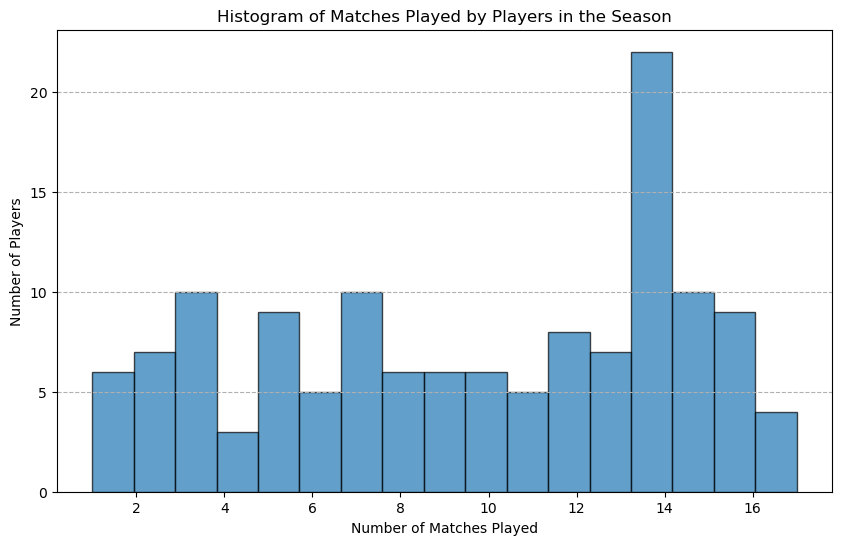

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(IPL_Dataset['Matches'], bins=17, edgecolor='black', alpha=0.7)

plt.xlabel("Number of Matches Played")
plt.ylabel("Number of Players")
plt.title("Histogram of Matches Played by Players in the Season")
plt.grid(axis='y', linestyle='--')

plt.show()

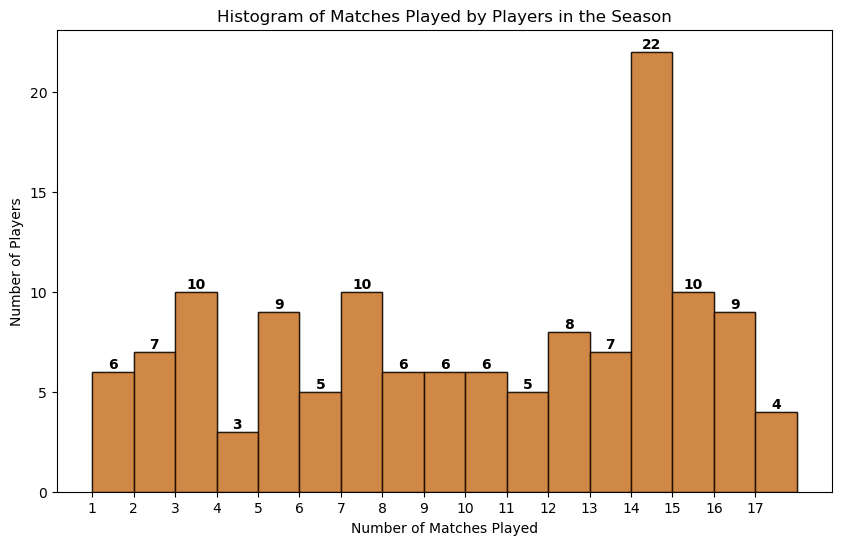

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(IPL_Dataset['Matches'], bins=range(min(IPL_Dataset['Matches']), max(IPL_Dataset['Matches']) + 2), edgecolor='black', alpha=0.7)

plt.xlabel("Number of Matches Played")
plt.ylabel("Number of Players")
plt.title("Histogram of Matches Played by Players in the Season")
plt.xticks(range(min(IPL_Dataset['Matches']), max(IPL_Dataset['Matches']) + 1))

counts, bins, patches = plt.hist(IPL_Dataset['Matches'], bins=range(min(IPL_Dataset['Matches']), max(IPL_Dataset['Matches']) + 2), edgecolor='black', alpha=0.7)
for patch, count in zip(patches, counts):
    plt.text(patch.get_x() + patch.get_width() / 2, patch.get_height(), str(int(count)), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


## Q14. Plot the histogram of balls faced by players.


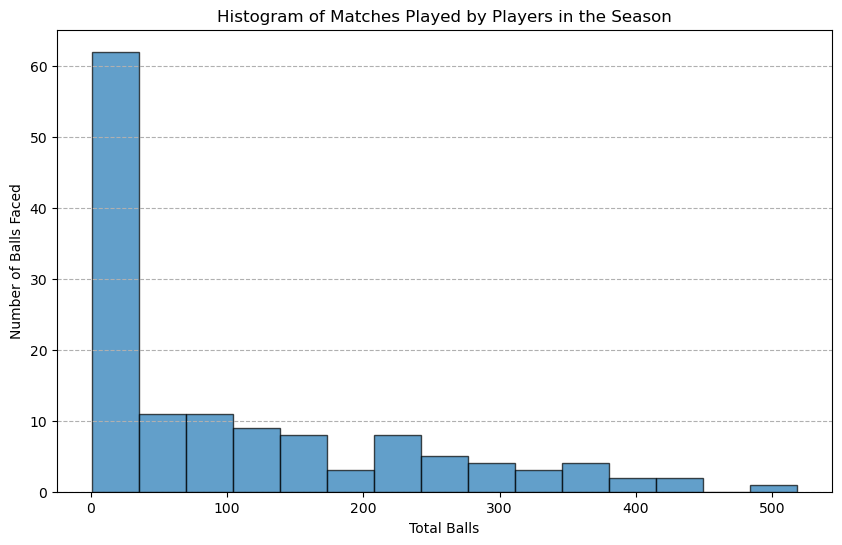

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(IPL_Dataset['Balls faced'], bins=15, edgecolor='black', alpha=0.7)

plt.xlabel("Total Balls")
plt.ylabel("Number of Balls Faced")
plt.title("Histogram of Matches Played by Players in the Season")
plt.grid(axis='y', linestyle='--')

plt.show()

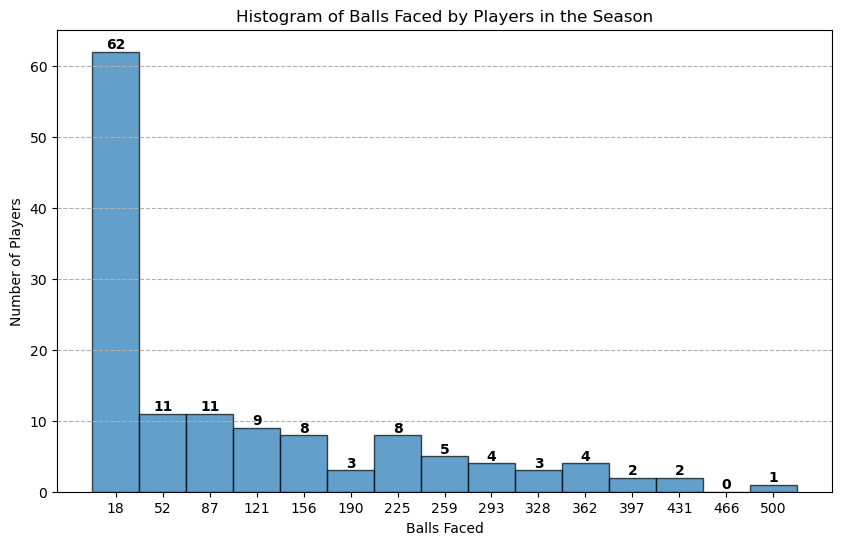

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(IPL_Dataset['Balls faced'], bins=15, edgecolor='black', alpha=0.7)

plt.xlabel("Balls Faced")
plt.ylabel("Number of Players")
plt.title("Histogram of Balls Faced by Players in the Season")

plt.grid(axis='y', linestyle='--')

bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]
plt.xticks(bin_centers, labels=[int(center) for center in bin_centers], rotation=0)

for i in range(len(patches)):
    plt.text(bin_centers[i], counts[i], str(int(counts[i])),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

## Q15. Top 10 players with most runs in a season.

In [27]:
top_10_players = IPL_Dataset[['Player', 'Runs']].sort_values(by='Runs', ascending=False).head(10)
print(top_10_players)

             Player  Runs
0          KL Rahul   670
1    Shikhar Dhawan   618
2      David Warner   548
3      Shreyas Iyer   519
4      Ishan Kishan   516
5      Quinton Kock   503
6  Suryakumar Yadav   480
7  Devdutt Padikkal   473
8       Virat Kohli   466
9      ABD Villiers   454


# Q16. Print the players who played the match but didn't get the batting.

In [29]:
Played_But_No_Batting = IPL_Dataset[(IPL_Dataset['Matches'] > 0) & (IPL_Dataset['Balls faced'] == 0 )]
print(Played_But_No_Batting[['Player']])

Empty DataFrame
Columns: [Player]
Index: []


## There is no player in the IPL_Dataset who played the match but didn't get the batting

## Reason - In order to fullfill the condition of batting. He must not face a single ball. But in the given IPL_dataset there is not even a single player who played 0 balls

## Q17. Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [30]:
IPL_Dataset['Boundary_Percentage'] = ((IPL_Dataset['4s']*4 + IPL_Dataset['6s']*6)/IPL_Dataset['Runs'])*100
Top_5_Boundary_Players = IPL_Dataset[['Player','Boundary_Percentage']].sort_values(by= 'Boundary_Percentage', ascending= False).head(5)
print(Top_5_Boundary_Players)

            Player  Boundary_Percentage
109     Andrew Tye           100.000000
48   Andre Russell            76.923077
74    Chris Morris            76.470588
29   Hardik Pandya            73.309609
47    Sunil Narine            72.727273


## Q18. Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [31]:
IPL_Dataset['Not_Out_Percentage'] = IPL_Dataset['Not Out']/IPL_Dataset['Inns']*100
Top_5_NotOut_Per = IPL_Dataset[['Player','Not_Out_Percentage']].sort_values(by= 'Not_Out_Percentage', ascending = False).head(5)
print(Top_5_NotOut_Per)

              Player  Not_Out_Percentage
122    Shahbaz Ahmed               100.0
97     Mohammad Nabi               100.0
114      T Natarajan               100.0
116     Rahul Chahar               100.0
113  Dhawal Kulkarni               100.0


## Q19. Create visualization of top 10 players with highest number of sixes.


In [32]:
Highest_Sixes_Player = IPL_Dataset[['Player','6s']].sort_values(by= '6s', ascending = False).head(10)
print(Highest_Sixes_Player)

             Player  6s
4      Ishan Kishan  30
15     Sanju Samson  26
29    Hardik Pandya  25
17  Nicholas Pooran  25
14      Eoin Morgan  24
9      ABD Villiers  23
27      Chris Gayle  23
0          KL Rahul  23
31   Kieron Pollard  22
5      Quinton Kock  22


C:\Users\user\AppData\Local\Temp\ipykernel_9436\805095472.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= 'Player', y= '6s', data= Highest_Sixes_Player, palette = 'viridis')


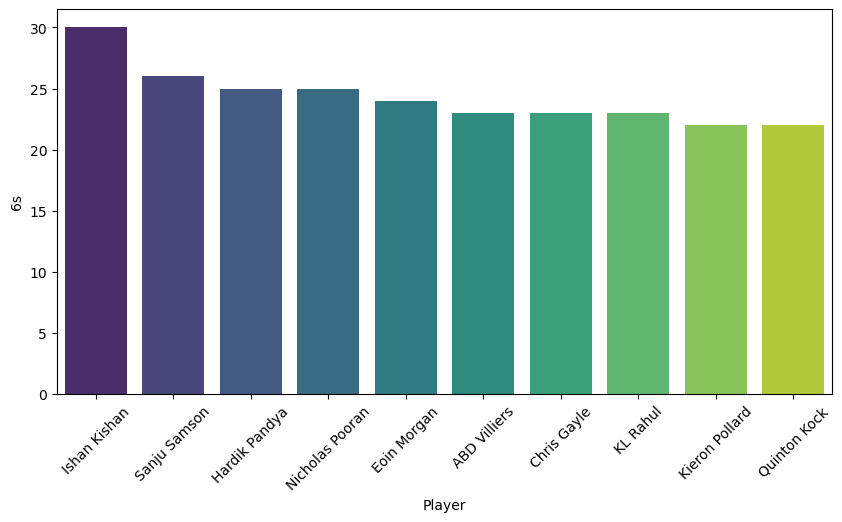

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (10,5))
sns.barplot(x= 'Player', y= '6s', data= Highest_Sixes_Player, palette = 'viridis')
plt.xlabel('Player')
plt.ylabel('6s')
plt.xticks(rotation= 45)
plt.show()

## Q20. Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.

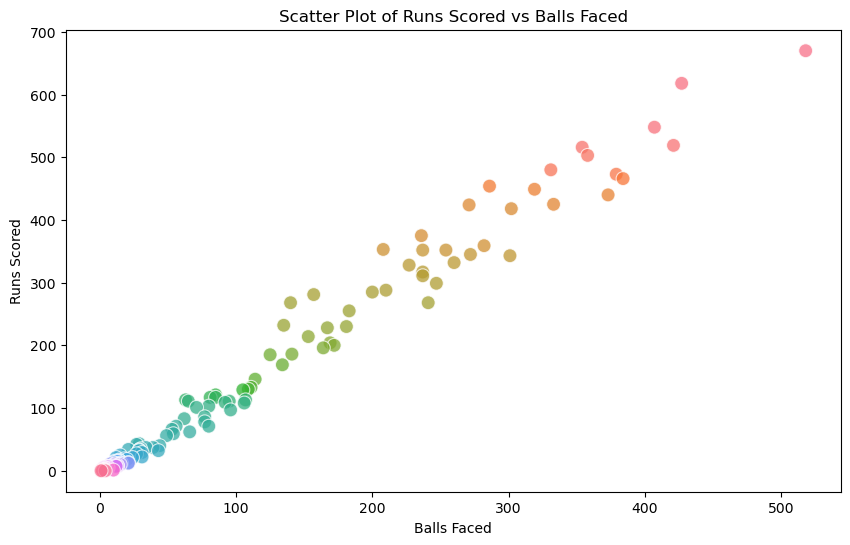

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x= IPL_Dataset["Balls faced"], y=IPL_Dataset["Runs"], hue=IPL_Dataset["Player"], palette="husl", s=100, alpha=0.75)

plt.xlabel("Balls Faced")
plt.ylabel("Runs Scored")
plt.title("Scatter Plot of Runs Scored vs Balls Faced")
plt.legend([],[], frameon=False) 

plt.show()

# From the above Scatter Plot we can infer that there is a positive co-relation between the Runs Scored and Balls Faced. And the density of the points are more between the range 0-100 so maximum players have faced balls between that range.

In [38]:
import scipy.stats as stats
correlation, p_value = stats.pearsonr(IPL_Dataset["Balls faced"], IPL_Dataset["Runs"])
print(f"Pearson Correlation Coefficient: {correlation}")

Pearson Correlation Coefficient: 0.9899480233860837
